# SHOW ME your WORK 💪

# Problem statement
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient

# Data Collection
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

In [108]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [109]:
# read the data
df = pd.read_csv('Travel.csv')

In [110]:
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [111]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

## Data Cleaning

In [113]:
(df.isna().sum()*100/len(df)).sort_values(ascending = False)

DurationOfPitch             5.135025
MonthlyIncome               4.766776
Age                         4.623568
NumberOfTrips               2.864157
NumberOfChildrenVisiting    1.350245
NumberOfFollowups           0.920622
PreferredPropertyStar       0.531915
TypeofContact               0.511457
CustomerID                  0.000000
ProdTaken                   0.000000
Gender                      0.000000
CityTier                    0.000000
ProductPitched              0.000000
NumberOfPersonVisiting      0.000000
Occupation                  0.000000
MaritalStatus               0.000000
PitchSatisfactionScore      0.000000
Passport                    0.000000
OwnCar                      0.000000
Designation                 0.000000
dtype: float64

small null percentage so we can replace it

In [114]:
# replacing nulls
num_cols = df.select_dtypes('number')
cat_cols = df.select_dtypes('object')
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isna().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [115]:
## outliers
def outlier_report(df):
        for col in num_cols:
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR=Q3-Q1
                lower_bound = Q1-1.5*IQR
                upper_bound = Q3+1.5*IQR

                outlier_count = ((df[col]<lower_bound)|(df[col]>upper_bound)).sum()
                outlier_per = (outlier_count/len(df))*100
                print(f"{col} : {outlier_per.__round__(3)}")

outlier_report(df)

CustomerID : 0.0
ProdTaken : 18.822
Age : 0.0
CityTier : 0.0
DurationOfPitch : 2.291
NumberOfPersonVisiting : 0.061
NumberOfFollowups : 6.383
PreferredPropertyStar : 0.0
NumberOfTrips : 2.23
Passport : 0.0
PitchSatisfactionScore : 0.0
OwnCar : 0.0
NumberOfChildrenVisiting : 0.0
MonthlyIncome : 7.672


In [116]:
df['NumberOfFollowups'].value_counts()

NumberOfFollowups
4.0    2113
3.0    1466
5.0     768
2.0     229
1.0     176
6.0     136
Name: count, dtype: int64

In [117]:
cap_cols = num_cols.drop('ProdTaken',axis=1)
for col in cap_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound = Q1-1.5*IQR
        upper_bound = Q3+1.5*IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [118]:
outlier_report(df)

CustomerID : 0.0
ProdTaken : 18.822
Age : 0.0
CityTier : 0.0
DurationOfPitch : 0.0
NumberOfPersonVisiting : 0.0
NumberOfFollowups : 0.0
PreferredPropertyStar : 0.0
NumberOfTrips : 0.0
Passport : 0.0
PitchSatisfactionScore : 0.0
OwnCar : 0.0
NumberOfChildrenVisiting : 0.0
MonthlyIncome : 0.0


In [119]:
for col in num_cols:
    print (f"{col} : {df[col].skew().round(2)}")
    

CustomerID : 0.0
ProdTaken : 1.6
Age : 0.42
CityTier : 0.74
DurationOfPitch : 0.94
NumberOfPersonVisiting : 0.02
NumberOfFollowups : -0.3
PreferredPropertyStar : 0.9
NumberOfTrips : 0.78
Passport : 0.92
PitchSatisfactionScore : -0.13
OwnCar : -0.5
NumberOfChildrenVisiting : 0.28
MonthlyIncome : 0.73


no extrem skewness

## Feature Engineering & Encoding

<Axes: >

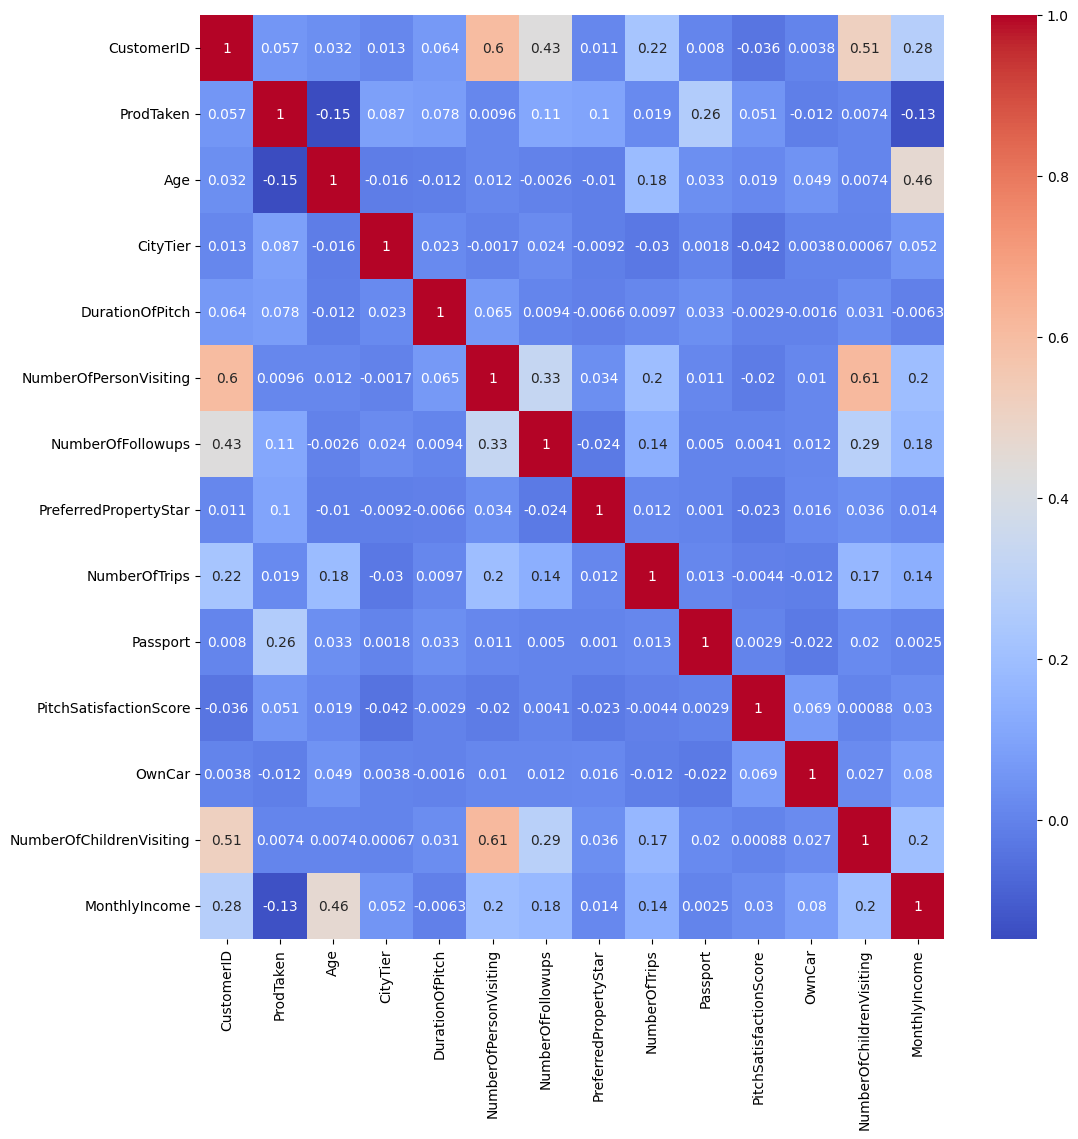

In [120]:
plt.figure(figsize=(12,12))
sns.heatmap(num_cols.corr(),annot=True , cmap='coolwarm')

In [121]:
#dropping customer id as it doen't affect the model and the NumberOfChildrenVisiting as it storngly related with the numberofpersonvisiting
df.drop('CustomerID', axis=1, inplace=True)
df.drop('NumberOfChildrenVisiting', axis=1, inplace=True)

In [122]:
cat_cols.nunique()

TypeofContact     2
Occupation        4
Gender            3
ProductPitched    5
MaritalStatus     4
Designation       5
dtype: int64

label encoding will be fine

In [123]:
# data splitting
from sklearn.model_selection import train_test_split
x = df.drop('ProdTaken',axis=1)
y= df['ProdTaken']

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [124]:
# encoding
from sklearn.preprocessing import StandardScaler,LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])


In [125]:
# scaling
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3.0,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3.0,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2.0,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2.0,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0


In [127]:
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [128]:
# handling implance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train_s, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: ProdTaken
0    3181
1     729
Name: count, dtype: int64
After SMOTE: ProdTaken
0    3181
1    3181
Name: count, dtype: int64


#### Build a classification model using support vector machine. Use standalone model as well as Bagging model and check if you see any difference in the performance.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC()

svm.fit(x_train_res, y_train_res)

y_pred = svm.predict(x_test_s)

print(classification_report(y_test, y_pred))

SVM Accuracy: 0.869120654396728
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       787
           1       0.64      0.76      0.70       191

    accuracy                           0.87       978
   macro avg       0.79      0.83      0.81       978
weighted avg       0.88      0.87      0.87       978



In [ ]:
from sklearn.ensemble import BaggingClassifier

bagging_svm = BaggingClassifier(
    estimator=SVC(),
    n_estimators=50,
    random_state=42
)

bagging_svm.fit(x_train_res, y_train_res)

y_pred_bag = bagging_svm.predict(x_test_s)

print(classification_report(y_test, y_pred_bag))

Bagging SVM Accuracy: 0.8660531697341514
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       787
           1       0.63      0.77      0.69       191

    accuracy                           0.87       978
   macro avg       0.78      0.83      0.80       978
weighted avg       0.88      0.87      0.87       978



In [134]:
print("Standalone SVM:", accuracy_score(y_test, y_pred))
print("Bagging SVM:", accuracy_score(y_test, y_pred_bag))

Standalone SVM: 0.869120654396728
Bagging SVM: 0.8660531697341514


#### Now use decision tree classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [135]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train_res, y_train_res)

y_pred_dt = dt.predict(x_test_s)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       787
           1       0.72      0.75      0.74       191

    accuracy                           0.90       978
   macro avg       0.83      0.84      0.84       978
weighted avg       0.90      0.90      0.90       978



In [136]:
from sklearn.ensemble import BaggingClassifier

bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging_dt.fit(x_train_res, y_train_res)

y_pred_bag_dt = bagging_dt.predict(x_test_s)

print(classification_report(y_test, y_pred_bag_dt))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       787
           1       0.86      0.74      0.79       191

    accuracy                           0.93       978
   macro avg       0.90      0.85      0.87       978
weighted avg       0.92      0.93      0.92       978



In [137]:
print("Standalone Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Bagging Decision Tree:", accuracy_score(y_test, y_pred_bag_dt))

Standalone Decision Tree: 0.8957055214723927
Bagging Decision Tree: 0.9253578732106339


#### then use random forest classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train_res, y_train_res)

y_pred_rf = rf.predict(x_test_s)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       787
           1       0.89      0.72      0.80       191

    accuracy                           0.93       978
   macro avg       0.91      0.85      0.88       978
weighted avg       0.93      0.93      0.93       978



In [142]:
from sklearn.ensemble import BaggingClassifier

bagging_rf = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=20,
    random_state=42
)

bagging_rf.fit(x_train_res, y_train_res)

y_pred_bag_rf = bagging_rf.predict(x_test_s)

print(classification_report(y_test, y_pred_bag_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       787
           1       0.84      0.65      0.74       191

    accuracy                           0.91       978
   macro avg       0.88      0.81      0.84       978
weighted avg       0.91      0.91      0.90       978



In [143]:
print("Standalone Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Bagging Random Forest:", accuracy_score(y_test, y_pred_bag_rf))

Standalone Random Forest: 0.9284253578732107
Bagging Random Forest: 0.908997955010225


#### Comparing performance of them to figure out where it makes most sense to use bagging and why. What conditions bagging works the best.

for the svm and descition tree bagging made the accurecy higher but in the random forest bagging made lower accurecy because random forest already uses bagging as it tries diffrent number of trees  
  
so the best application is using the descition tree with baging